# 23. Live Tutorial 2: From Minitab to Six Factors — Two Ways to Read an Effect

Every DoE practitioner eventually makes this comparison: a point-and-click
tool walks you through a factorial analysis one dialog box at a time, and
you want to know whether the same analysis, done in a few lines of Python,
gives the identical answer. Part A recreates that comparison directly —
in the style of a Minitab "DOE — Full Factorial Analysis" walkthrough —
on a small, synthetic 3-factor materials study. Part B then raises the
stakes with **real, published textbook data**: Box & Draper's 2⁶
full-factorial study (*Empirical Model-Building and Response Surfaces*,
Wiley 1984, Ch. 4), 64 genuine experimental runs and 6 factors, analysed
first by hand (Yates' contrast method) and then by an auto-generated
`statsmodels` formula — plus a screening tool built specifically for
designs with no replication at all: the normal-probability plot.

**Session plan**
1. From a video to Python: a 3-factor sintering study
2. Fitting the full model — and why it has zero residual degrees of freedom
3. Pareto chart, model reduction, and confirmation
4. Raising the stakes: Box & Draper's six-factor study
5. Computing effects by hand — the Yates method
6. The same effects, automatically — statsmodels OLS
7. Screening without replication: Pareto and normal-probability plots
8. Reading the result: what the book says

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product, combinations
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels.graphics.gofplots as smg

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(606)

## 23.1 From a Video to Python: A 3-Factor Sintering Study

**Hot-pressing a ceramic pellet**: three process factors, response =
relative density (%TD, percent of theoretical density), 5 replicate
pellets pressed at each of the 8 corner settings.

| Factor | Low ($-1$) | High ($+1$) |
|---|---|---|
| A — Dwell time | 1 h | 3 h |
| B — Temperature | 1000°C | 1200°C |
| C — Pressure | 10 MPa | 30 MPa |

Exactly as a Minitab walkthrough would, we first record each factor's real
low/high values, then encode them to $\pm 1$ using the span-and-average
trick — this is what makes "the coefficient on A" mean the same thing
regardless of whether A is measured in hours, °C, or MPa.

In [2]:
factor_ranges = {
    'A': ('Dwell_time_h', 1.0, 3.0),
    'B': ('Temperature_C', 1000.0, 1200.0),
    'C': ('Pressure_MPa', 10.0, 30.0),
}
inputs_df = pd.DataFrame(
    [(k, lo, hi, label) for k, (label, lo, hi) in factor_ranges.items()],
    columns=['factor', 'low', 'high', 'label']
).set_index('factor')
inputs_df['average'] = (inputs_df['low'] + inputs_df['high']) / 2
inputs_df['span'] = (inputs_df['high'] - inputs_df['low']) / 2
inputs_df

,low,high,label,average,span
factor,,,,,
A,1.0,3.0,Dwell_time_h,2.0,1.0
B,1000.0,1200.0,Temperature_C,1100.0,100.0
C,10.0,30.0,Pressure_MPa,20.0,10.0


In [3]:
encoded_inputs = list(product([-1, 1], [-1, 1], [-1, 1]))
results = pd.DataFrame(encoded_inputs, columns=['A', 'B', 'C'])

# Decode coded -1/+1 back to real units -- the video's span+average trick, in reverse
for f in ['A', 'B', 'C']:
    results[inputs_df.loc[f, 'label']] = inputs_df.loc[f, 'average'] + results[f] * inputs_df.loc[f, 'span']
results

,A,B,C,Dwell_time_h,Temperature_C,Pressure_MPa
0,-1,-1,-1,1.0,1000.0,10.0
1,-1,-1,1,1.0,1000.0,30.0
2,-1,1,-1,1.0,1200.0,10.0
3,-1,1,1,1.0,1200.0,30.0
4,1,-1,-1,3.0,1000.0,10.0
5,1,-1,1,3.0,1000.0,30.0
6,1,1,-1,3.0,1200.0,10.0
7,1,1,1,3.0,1200.0,30.0


In [4]:
# True process (coded units): dwell time (A) and pressure (C) both raise density,
# temperature (B) barely matters in this range, and there's a genuine A:C synergy
# (longer dwell matters more when pressure is also high) -- everything else is noise.
A, B, C = results['A'], results['B'], results['C']
true_density = 92.0 + 3.5*A + 0.3*B + 2.0*C + 1.2*A*C

n_reps = 5
Y = true_density.values[:, None] + rng.normal(0, 0.3, size=(len(results), n_reps))
for i in range(n_reps):
    results[f'Y{i+1}'] = Y[:, i].round(2)

results['y'] = results[[f'Y{i+1}' for i in range(n_reps)]].mean(axis=1)
results['s'] = results[[f'Y{i+1}' for i in range(n_reps)]].std(axis=1)
results[['A', 'B', 'C', 'Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'y', 's']]

,A,B,C,Y1,Y2,Y3,Y4,Y5,y,s
0,-1,-1,-1,87.48,87.89,87.51,87.69,87.62,87.638,0.164225
1,-1,-1,1,89.22,88.57,89.37,89.18,88.60,88.988,0.374793
2,-1,1,-1,87.79,87.89,88.56,88.45,87.97,88.132,0.348597
3,-1,1,1,89.41,89.29,89.31,89.39,89.43,89.366,0.062290
4,1,-1,-1,92.16,91.94,91.66,92.15,92.07,91.996,0.207437
5,1,-1,1,98.13,98.26,98.71,98.46,98.42,98.396,0.219386
6,1,1,-1,92.45,92.24,92.52,92.87,92.86,92.588,0.273075
7,1,1,1,99.36,99.68,99.20,99.24,98.92,99.280,0.275681


## 23.2 Fitting the Full Model — and Why It Has Zero Residual Degrees of Freedom

First check whether the **scatter itself** depends on the settings — a
real process-control question, not just a formality: if pressure also
controls how *repeatable* the density is, that matters as much as the
average density itself.

In [5]:
mod_s = smf.ols('s ~ A + B + C + A:B + A:C + B:C', data=results).fit()
print(mod_s.params.round(3))
print(f'\nLargest |coefficient|: {mod_s.params.drop("Intercept").abs().max():.3f} -- '
      'no term stands out; replicate-to-replicate scatter looks like pure measurement noise.')

Intercept    0.241
A            0.003
B           -0.001
C           -0.008
A:B          0.031
A:C          0.011
B:C         -0.063
dtype: float64

Largest |coefficient|: 0.063 -- no term stands out; replicate-to-replicate scatter looks like pure measurement noise.


In [6]:
mod_full = smf.ols('y ~ A * B * C', data=results).fit()
print(mod_full.params.round(3))
print(f'\nResidual df: {int(mod_full.df_resid)}  (8 corner averages - 8 parameters)')
print('Zero residual degrees of freedom: the full model fits the 8 corner averages')
print('exactly, so there is no p-value or F-test available for any term -- only the')
print('coefficients themselves, ranked by magnitude, are usable for screening. This is')
print('exactly the situation a Minitab full-factorial walkthrough runs into as well.')

Intercept    92.048
A             3.517
B             0.293
A:B           0.075
C             1.959
A:C           1.314
B:C           0.022
A:B:C         0.051
dtype: float64

Residual df: 0  (8 corner averages - 8 parameters)
Zero residual degrees of freedom: the full model fits the 8 corner averages
exactly, so there is no p-value or F-test available for any term -- only the
coefficients themselves, ranked by magnitude, are usable for screening. This is
exactly the situation a Minitab full-factorial walkthrough runs into as well.


## 23.3 Pareto Chart, Model Reduction, and Confirmation

With no p-values to rank by, fall back on **magnitude**: a Pareto chart of
the standardized effects (twice each coefficient, same convention as
Notebook 22), sorted largest to smallest, with a cumulative-percentage
line to separate the "vital few" from the "trivial many" — the same 80/20
logic behind every Pareto chart in this course.

       standardized_effect  cum_pct
A                    7.034     48.6
C                    3.919     75.7
A:C                  2.627     93.9
B                    0.587     97.9
A:B                  0.151     99.0
A:B:C                0.102     99.7
B:C                  0.044    100.0


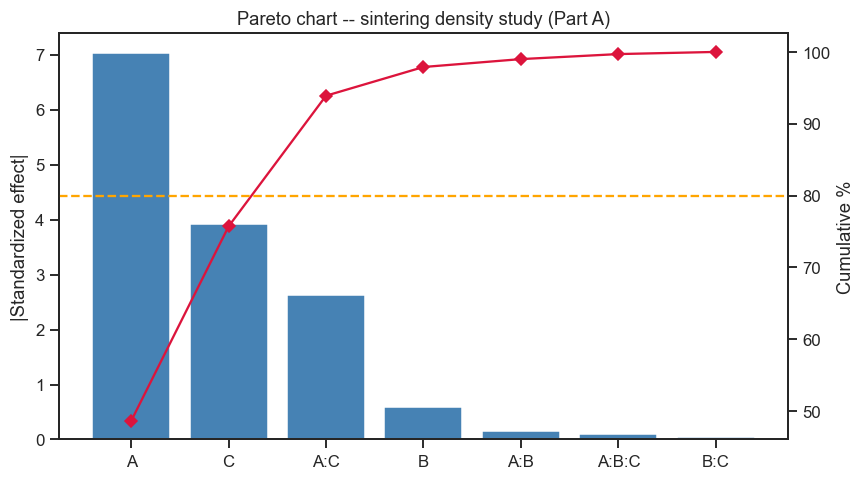

In [7]:
effects = (2 * mod_full.params.drop('Intercept')).abs().sort_values(ascending=False)
effects_df = effects.to_frame('standardized_effect')
effects_df['cum_pct'] = (effects_df['standardized_effect'].cumsum()
                          / effects_df['standardized_effect'].sum() * 100).round(1)
print(effects_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(effects_df.index, effects_df['standardized_effect'], color='steelblue')
ax2 = ax.twinx()
ax2.plot(effects_df.index, effects_df['cum_pct'], color='crimson', marker='D')
ax2.axhline(80, color='orange', linestyle='dashed')
ax.set_ylabel('|Standardized effect|'); ax2.set_ylabel('Cumulative %')
ax.set_title('Pareto chart -- sintering density study (Part A)')
plt.tight_layout()
plt.show()

:::{admonition} Take-home message
:class: tip

`A` (dwell time, effect 7.03) and `C` (pressure, effect 3.92) together
already cover 75.7% of the cumulative standardized effect; `A:C`
(effect 2.63) pushes that to 93.9%, and `B` (0.59) and the remaining
interactions trail far behind, together barely 6%. This matches the true
built-in structure closely — true effects of 7.0 (`A`), 4.0 (`C`), 2.4
(`A:C`), and 0.6 (`B`) — though as Section 23.3's next cell shows, "close
to the true ranking" and "clears an 80% cumulative cutoff" are not always
the same thing.
:::

In [8]:
keep_terms = effects_df[effects_df['cum_pct'] <= 80].index.tolist()
if not keep_terms:                      # always keep at least the single largest term
    keep_terms = [effects_df.index[0]]
print('Terms kept (cumulative <= 80%):', keep_terms)

formula_reduced = 'y ~ ' + ' + '.join(keep_terms)
mod_reduced_A = smf.ols(formula_reduced, data=results).fit()
print(mod_reduced_A.summary().tables[1])

Terms kept (cumulative <= 80%): ['A', 'C']
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     92.0480      0.603    152.559      0.000      90.497      93.599
A              3.5170      0.603      5.829      0.002       1.966       5.068
C              1.9595      0.603      3.248      0.023       0.409       3.510


:::{admonition} Take-home message
:class: tip

The mechanical 80%-cumulative rule keeps only `A` and `C` here — `A:C`'s
cumulative total (93.9%) falls just past the 80% line, so a strict
cutoff drops a genuinely real interaction (true effect 2.4) purely
because of where the cumulative percentage happened to cross 80% after
`C`. The 2-term reduced model still fits well (R²=0.899) and both
coefficients land close to true (`A`: fitted 3.517 vs. true 3.5; `C`:
fitted 1.960 vs. true 2.0), so this isn't a *bad* model — but it is a
reminder that an 80% cumulative threshold, like any rule of thumb, is a
starting point for judgement, not a substitute for it. A Minitab analyst
eyeballing the same chart, seeing the clear gap between `A:C` and `B`,
would likely have kept `A:C` too.
:::

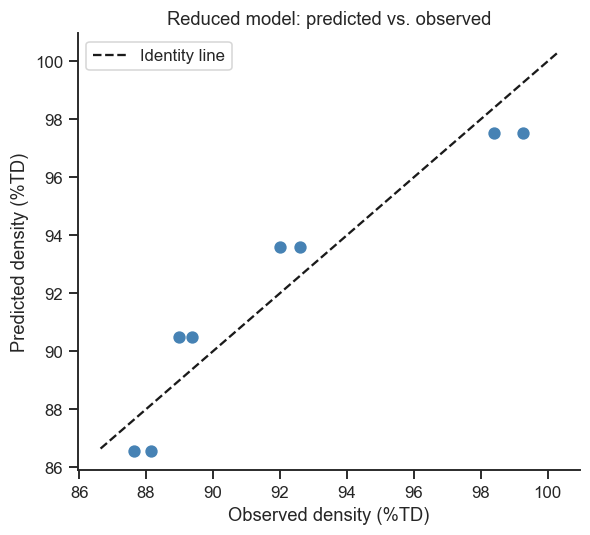

Reduced model R2 = 0.8990


In [9]:
results['y_pred'] = mod_reduced_A.predict(results)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(results['y'], results['y_pred'], color='steelblue', s=50)
lims = [results['y'].min() - 1, results['y'].max() + 1]
ax.plot(lims, lims, 'k--', label='Identity line')
ax.set_xlabel('Observed density (%TD)'); ax.set_ylabel('Predicted density (%TD)')
ax.set_title('Reduced model: predicted vs. observed'); ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f'Reduced model R2 = {mod_reduced_A.rsquared:.4f}')

**Checkpoint**: does `keep_terms` recover `A` and `C` — the two largest
terms actually built into `true_density` — and correctly leave out `B`?
Then look at where `A:C` (also genuinely built in, but smaller) falls
relative to the 80% cumulative line: is it kept or dropped, and does that
match what you'd have chosen by eye from the Pareto chart? This is the
same reduction logic as Notebook 24 (Live Tutorial 3) §24.2, just driven
by effect magnitude instead of a p-value, because Section 23.2 showed
there are no p-values available here at all.

## 23.4 Raising the Stakes: Box & Draper's Six-Factor Study

Part A was small and synthetic — 8 runs, 3 factors, invented numbers.
Part B uses **genuine published data**: a $2^6$ full-factorial study from
Box & Draper's *Empirical Model-Building and Response Surfaces* (Wiley,
1984), Chapter 4 — 64 real experimental runs, 6 coded factors
($x_1,\ldots,x_6$), and 3 recorded response variables. We work with
$y_1$ throughout this section (Exercise 2 asks you to repeat the analysis
for $y_2$ or $y_3$). The same two techniques from Part A — manual
contrast-based effects and a `statsmodels` OLS fit — scale up completely
unchanged; only the *practicality* of writing out the model formula by
hand changes, which is exactly the problem Section 23.6 solves.

In [10]:
encoded_inputs6 = list(product([-1, 1], [-1, 1], [-1, 1], [-1, 1], [-1, 1], [-1, 1]))
doe = pd.DataFrame(encoded_inputs6)
doe = doe[doe.columns[::-1]]
doe.columns = [f'x{i+1}' for i in range(6)]

# Real published data: Box & Draper (1984), Ch. 4 -- three response variables
# recorded from the same 64-run 2^6 design.
doe['y1'] = [3.4, 9.7, 7.4, 10.6, 6.5, 7.9, 10.3, 9.5, 14.3, 10.5, 7.8, 17.2, 9.4, 12.1, 9.5, 15.8, 8.3, 8.0, 7.9, 10.7, 7.2, 7.2, 7.9, 10.2, 10.3, 9.9, 7.4, 10.5, 9.6, 15.1, 8.7, 12.1, 12.6, 10.5, 11.3, 10.6, 8.1, 12.5, 11.1, 12.9, 14.6, 12.7, 10.8, 17.1, 13.6, 14.6, 13.3, 14.4, 11.0, 12.5, 8.9, 13.1, 7.6, 8.6, 11.8, 12.4, 13.4, 14.6, 14.9, 11.8, 15.6, 12.8, 13.5, 15.8]
doe['y2'] = [15,5,23, 8,20, 9, 13, 5, 23, 1, 11, 5, 15, 8, 15, 1, 22, 8, 16, 7, 25, 5, 17, 8, 10, 3, 22, 6, 24, 4, 10, 5, 32, 10, 28, 18, 22, 31, 17, 16, 38, 12, 34, 19, 12, 14, 25, 16, 31, 14, 23, 23, 28, 20, 18, 11, 39, 30, 31, 6, 33, 23, 31, 11]
doe['y3'] = [36, 35, 37, 34, 30, 32, 28, 38, 40, 32, 32, 28, 34, 26,  30, 28, 40, 30, 35, 35, 32, 35, 36, 32, 20, 35, 35, 28, 27, 36, 36, 35, 32, 34, 30, 24, 30, 20, 32, 25, 20, 20, 22, 35, 26, 15, 19, 24, 22, 23, 22, 18, 20, 20, 20, 36, 20, 11, 20, 35, 16, 32, 20, 20]
print(f'{len(doe)} runs, 6 factors, 3 response variables (y1, y2, y3).')
doe[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y1', 'y2', 'y3']].head()

64 runs, 6 factors, 3 response variables (y1, y2, y3).


,x1,x2,x3,x4,x5,x6,y1,y2,y3
0,-1,-1,-1,-1,-1,-1,3.4,15,36
1,1,-1,-1,-1,-1,-1,9.7,5,35
2,-1,1,-1,-1,-1,-1,7.4,23,37
3,1,1,-1,-1,-1,-1,10.6,8,34
4,-1,-1,1,-1,-1,-1,6.5,20,30


## 23.5 Computing Effects by Hand — The Yates Method

The same contrast formula from Notebook 22 §22.2 generalises cleanly to
any number of factors: for a $k$-way interaction, the "column" is simply
the elementwise product of the $k$ individual coded columns, and the
effect is that contrast divided by $n/2$ ($n=64$ runs here, so $n/2=32$).

In [11]:
labels = {1: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']}
for k in [2, 3, 4, 5, 6]:
    labels[k] = list(combinations(labels[1], k))

effects_y1 = {}
for k in [1, 2, 3, 4, 5, 6]:
    for combo in labels[k]:
        factors = (combo,) if k == 1 else combo   # k=1 entries are bare strings, not tuples
        sign = np.prod([doe[f] for f in factors], axis=0)
        effects_y1[combo] = (sign * doe['y1']).sum() / 32   # n/2 = 64/2 = 32

effects_series = pd.Series(effects_y1)
print(f'{len(effects_series)} effects computed by hand for y1 '
      f'(main effects through the 6-way interaction, 2^6 - 1 = 63 terms).')
print(effects_series.abs().sort_values(ascending=False).head(10))

63 effects computed by hand for y1 (main effects through the 6-way interaction, 2^6 - 1 = 63 terms).
x4                      2.984375
x6                      2.690625
x1                      1.746875
(x1, x2, x4, x5)        1.159375
(x1, x2)                0.890625
(x2, x4)                0.859375
(x1, x6)                0.821875
(x1, x2, x4)            0.815625
(x1, x3, x4, x6)        0.765625
(x1, x2, x3, x4, x6)    0.740625
dtype: float64


## 23.6 The Same Effects, Automatically — statsmodels OLS

Writing a 63-term formula string by hand for 6 factors is not realistic —
this is precisely where a Minitab-style point-and-click tool starts to
look genuinely convenient, and precisely where a few lines of Python that
*generate* the formula string win the comparison back.

In [12]:
terms = [combo if isinstance(combo, str) else ':'.join(combo)
         for k in [1, 2, 3, 4, 5, 6] for combo in labels[k]]
formula_full6 = 'y1 ~ ' + ' + '.join(terms)
print(f'{len(terms)} terms in the auto-generated formula '
      f'(2^6 - 1 = 63, matching the effects computed by hand above).')

mod_y1 = smf.ols(formula_full6, data=doe).fit()
print(f'Residual df: {int(mod_y1.df_resid)}  (64 runs - 64 parameters -- '
      'the same zero-df situation as Part A, at 8x the scale.)')

63 terms in the auto-generated formula (2^6 - 1 = 63, matching the effects computed by hand above).
Residual df: 0  (64 runs - 64 parameters -- the same zero-df situation as Part A, at 8x the scale.)


In [13]:
ols_effects = (2 * mod_y1.params.drop('Intercept')).abs()

# Match manual-effect names (tuples for multi-factor terms) to statsmodels' 'x1:x2' keys
manual_named = effects_series.abs()
manual_named.index = [':'.join(k) if isinstance(k, tuple) else k for k in manual_named.index]

compare = pd.DataFrame({'manual_Yates': manual_named, 'statsmodels_2xOLS': ols_effects})
compare = compare.sort_values('manual_Yates', ascending=False)
print(compare.head(8).round(4))
print(f'\nMax absolute difference across all 63 effects: '
      f'{(compare["manual_Yates"] - compare["statsmodels_2xOLS"]).abs().max():.6f}')

             manual_Yates  statsmodels_2xOLS
x4                 2.9844             2.9844
x6                 2.6906             2.6906
x1                 1.7469             1.7469
x1:x2:x4:x5        1.1594             1.1594
x1:x2              0.8906             0.8906
x2:x4              0.8594             0.8594
x1:x6              0.8219             0.8219
x1:x2:x4           0.8156             0.8156

Max absolute difference across all 63 effects: 0.000000


:::{admonition} Take-home message
:class: tip

The manual Yates effects and the `2 × statsmodels` coefficients agree to
**0.000000** across all 63 terms — not "close," identical to floating-point
precision. This is Notebook 22 §22.2's checkpoint again, now demonstrated
at 6 factors and 63 terms instead of 2 factors and 3: a factorial effect
is a regression coefficient in different units, full stop, regardless of
how many factors are involved or which method computed it first.
:::

## 23.7 Screening Without Replication: Pareto and Normal-Probability Plots

With 64 unreplicated runs and 63 possible effects, there is no pure-error
degrees of freedom for a formal F-test — the same zero-df situation as
Section 23.2, just at 8× the scale, and now with far too many bars for a
Pareto chart alone to read comfortably. The **normal-probability (QQ)
plot** solves this directly: if every effect were pure noise, the sorted
effects would fall on a straight line against their theoretical normal
quantiles; genuinely active effects break away from that line, and you
don't need to pick a magnitude threshold by eye to see it.

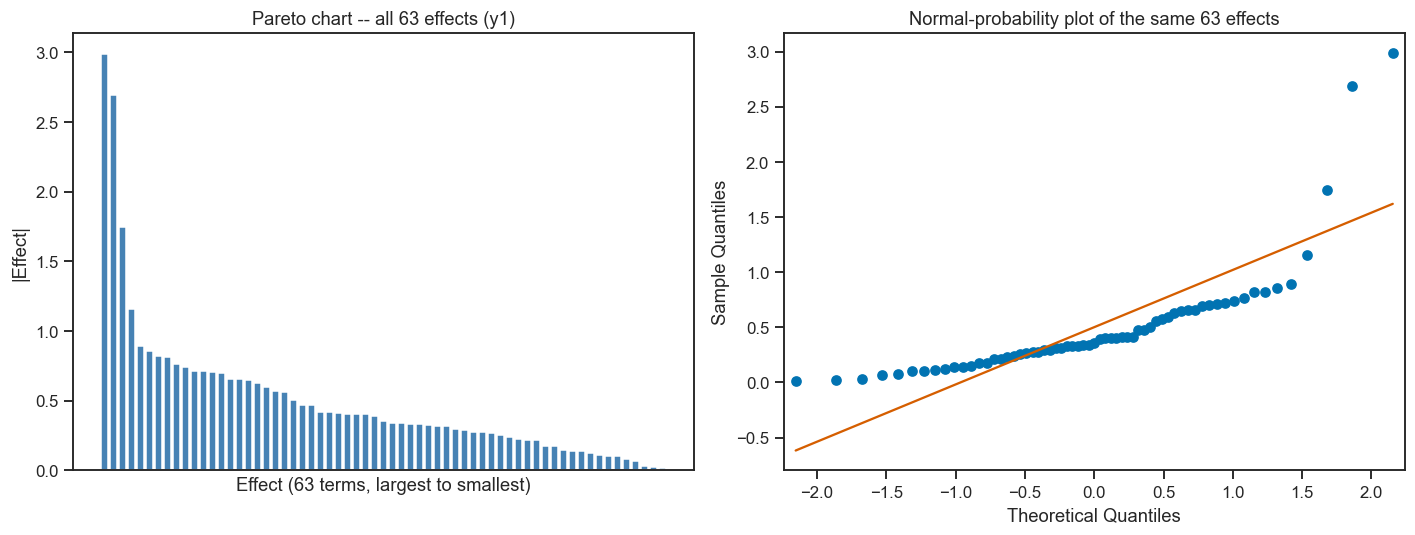

Largest 6 effects by magnitude:
x4             2.984375
x6             2.690625
x1             1.746875
x1:x2:x4:x5    1.159375
x1:x2          0.890625
x2:x4          0.859375
dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sorted_effects = ols_effects.sort_values(ascending=False)
axes[0].bar(range(len(sorted_effects)), sorted_effects.values, color='steelblue')
axes[0].set_xticks([])
axes[0].set_xlabel('Effect (63 terms, largest to smallest)')
axes[0].set_ylabel('|Effect|')
axes[0].set_title('Pareto chart -- all 63 effects (y1)')

smg.ProbPlot(ols_effects.values).qqplot(line='s', ax=axes[1])
axes[1].set_title('Normal-probability plot of the same 63 effects')

plt.tight_layout()
plt.show()

print('Largest 6 effects by magnitude:')
print(sorted_effects.head(6))

:::{admonition} Take-home message
:class: tip

The three largest effects — `x4` (2.98), `x6` (2.69), `x1` (1.75) — are
exactly the three terms Box & Draper's own analysis singles out (Section
23.8). But the break is not a clean cliff: the fourth-largest effect,
`x1:x2:x4:x5` (1.16), is a 4-way interaction bigger than several
2-way interactions further down the list, and the decline from there
(0.89, 0.86, 0.82, ...) is gradual rather than sharp. With 63 unreplicated
effects, both the Pareto chart and the normal-probability plot narrow the
field usefully, but neither hands you an unambiguous stopping point on
its own here — a genuine, honest limitation of magnitude-only screening,
and exactly why Section 23.8 leans on the published analysis (which had
the benefit of domain knowledge about which interactions are physically
plausible) rather than a purely mechanical rule.
:::

**Checkpoint**: which effects visibly break away from the straight line
of small, noise-like effects bunched near the origin of the
normal-probability plot? Keep your answer in mind for Section 23.8.

## 23.8 Reading the Result: What the Book Says

Box & Draper's own analysis of this dataset settles on three dominant
terms for $y_1$: $x_1$, $x_4$, and $x_6$. Fit that reduced model, check
its residual standard deviation two independent ways, and look at both a
predicted-vs-observed plot and a residual plot — the same confirmation
habit as Notebook 22 §22.5, now applied to a real published result
instead of a synthetic one.

In [15]:
mod_final = smf.ols('y1 ~ x1 + x4 + x6', data=doe).fit()
print(mod_final.summary().tables[1])
print(f'\nResidual standard deviation: {mod_final.scale**0.5:.3f}  '
      f'(matches sqrt(sum(resid^2)/df_resid) = '
      f'{np.sqrt(np.sum(mod_final.resid**2) / mod_final.df_resid):.3f})')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.1234      0.238     46.741      0.000      10.647      11.599
x1             0.8734      0.238      3.670      0.001       0.397       1.349
x4             1.4922      0.238      6.270      0.000       1.016       1.968
x6             1.3453      0.238      5.653      0.000       0.869       1.821

Residual standard deviation: 1.904  (matches sqrt(sum(resid^2)/df_resid) = 1.904)


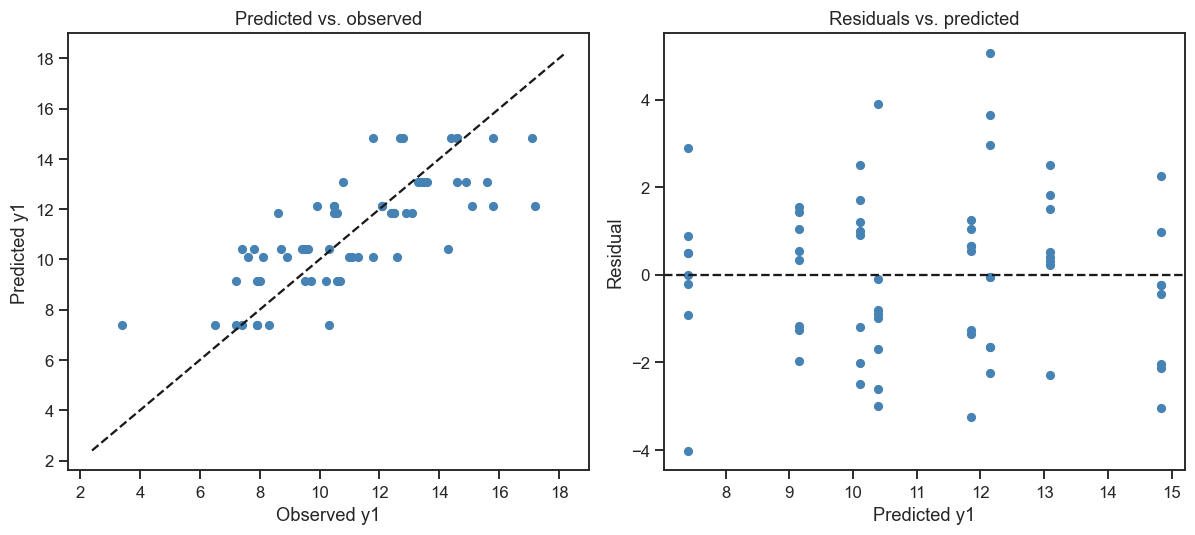

Reduced model (x1, x4, x6 only): R2=0.585, R2_adj=0.565


In [16]:
doe['y1_pred'] = mod_final.predict(doe)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(doe['y1'], doe['y1_pred'], color='steelblue', s=25)
lims = [doe['y1'].min() - 1, doe['y1'].max() + 1]
axes[0].plot(lims, lims, 'k--')
axes[0].set_xlabel('Observed y1'); axes[0].set_ylabel('Predicted y1')
axes[0].set_title('Predicted vs. observed')

axes[1].scatter(doe['y1_pred'], mod_final.resid, color='steelblue', s=25)
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_xlabel('Predicted y1'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. predicted')

plt.tight_layout()
plt.show()

print(f'Reduced model (x1, x4, x6 only): R2={mod_final.rsquared:.3f}, '
      f'R2_adj={mod_final.rsquared_adj:.3f}')

:::{admonition} Take-home message
:class: tip

All three terms are significant (p≤0.001) and each fitted coefficient is
exactly half its Section 23.5/23.6 effect — `x1`: 0.873 (effect 1.747),
`x4`: 1.492 (effect 2.984), `x6`: 1.345 (effect 2.691) — the same
coefficient-equals-half-the-effect relationship checked in every factorial
notebook so far. With only 3 of 63 possible terms, the model explains a
real but modest 58.5% of the variance in $y_1$ (R²_adj=0.565) and has a
residual standard deviation of 1.90 against $y_1$ values ranging roughly
3–17 — a genuinely useful screening result on real data, not a
picture-perfect fit, which is an honest note to end on: real published
data rarely reduces as cleanly as a synthetic teaching example does.
:::

---
## Exercises

**Core practice**

1. **A different dominant factor**: Redo Part A (Sections 23.1–23.3) with
   a different `true_density` — make `B` (temperature) the dominant term
   instead of `A`, and remove the `A:C` interaction. Confirm the Pareto
   chart and the automatic 80%-cumulative reduction correctly identify the
   new dominant factor.

2. **Repeat for $y_2$ or $y_3$**: Redo Sections 23.5–23.8 for one of the
   other two Box & Draper response variables. Which of $x_1,\ldots,x_6$
   turn out to matter for that response, and how much overlap is there
   with the terms that mattered for $y_1$?

**Deeper practice**

3. **When does the formula-generation trick stop being optional?**
   Section 23.6's auto-generated formula has 63 terms for 6 factors.
   Work out how many terms a full factorial model would need for 8
   factors, and for 10 — at what point does writing the formula by hand
   go from "tedious but possible" to "not realistically possible without
   a bug"?

4. **A fractional alternative**: Fit a Resolution IV half-fraction
   (`pyDOE3.fracfact`, Notebook 18) of the 6-factor design instead of the
   full 64 runs, using only the 32 runs it selects. Is the reduced model
   from Section 23.8 ($x_1$, $x_4$, $x_6$) still recoverable, and what
   happens to any of those three terms that turn out to be aliased with
   each other on the half-fraction?